Load the CSV Data into a Pandas DataFrame

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

# un-comment for google colab
# from google.colab import files
# uploaded = files.upload()

df = pd.read_csv("listings.csv")
df.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,1419,https://www.airbnb.com/rooms/1419,2.025110e+13,2025-11-11,previous scrape,Beautiful home in amazing area!,"This large, family home is located in one of T...",The apartment is located in the Ossington stri...,https://a0.muscache.com/pictures/76206750/d643...,1565,...,5.00,5.00,5.00,NaN,f,1,1,0,0,0.05
1,8077,https://www.airbnb.com/rooms/8077,2.025110e+13,2025-11-11,previous scrape,Downtown Harbourfront Private Room,Guest room in a luxury condo with access to al...,NaN,https://a0.muscache.com/pictures/11780344/141c...,22795,...,4.90,4.92,4.83,NaN,f,2,1,1,0,0.85
2,26654,https://www.airbnb.com/rooms/26654,2.025110e+13,2025-11-11,city scrape,"World Class @ CN Tower, convention centre, The...","CN Tower, TIFF Bell Lightbox, Metro Convention...",There's a reason they call it the Entertainmen...,https://a0.muscache.com/pictures/81811785/5dcd...,113345,...,4.78,4.87,4.69,NaN,f,3,3,0,0,0.25
3,27423,https://www.airbnb.com/rooms/27423,2.025110e+13,2025-11-12,city scrape,Executive Studio Unit- Ideal for One Person,"Brand new, fully furnished studio basement apa...",NaN,https://a0.muscache.com/pictures/176936/b687ed...,118124,...,5.00,4.88,4.88,NaN,f,1,1,0,0,0.16
4,30931,https://www.airbnb.com/rooms/30931,2.025110e+13,2025-11-11,previous scrape,Downtown Toronto - Waterview Condo,Split level waterfront condo with a breathtaki...,NaN,https://a0.muscache.com/pictures/227971/e8ebd7...,22795,...,NaN,NaN,NaN,NaN,f,2,1,1,0,0.01


Basic Inspection

In [5]:
print("Shape of dataset:", df.shape)
print("\nFirst 10 column names:")
print(df.columns[:10].tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values (top 20):")
print(df.isnull().sum().sort_values(ascending=False).head(20))

Shape of dataset: (21468, 79)

First 10 column names:
['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name', 'description', 'neighborhood_overview', 'picture_url', 'host_id']

Data types:
id                                                int64
listing_url                                         str
scrape_id                                       float64
last_scraped                                        str
source                                              str
                                                 ...   
calculated_host_listings_count                    int64
calculated_host_listings_count_entire_homes       int64
calculated_host_listings_count_private_rooms      int64
calculated_host_listings_count_shared_rooms       int64
reviews_per_month                               float64
Length: 79, dtype: object

Missing values (top 20):
neighbourhood_group_cleansed    21468
calendar_updated                21468
host_neighbourhood              14025
neighborhood_ove

Keeping only relevant columns

In [6]:
keep_cols = [
    "id",
    "name",
    "host_id",
    "host_response_time",
    "host_response_rate",
    "host_is_superhost",
    "neighbourhood_cleansed",
    "latitude",
    "longitude",
    "property_type",
    "room_type",
    "accommodates",
    "bathrooms",
    "bathrooms_text",
    "bedrooms",
    "beds",
    "amenities",
    "price",
    "minimum_nights",
    "availability_30",
    "availability_60",
    "availability_90",
    "availability_365",
    "number_of_reviews",
    "number_of_reviews_ltm",
    "estimated_occupancy_l365d",
    "estimated_revenue_l365d",
    "review_scores_rating",
    "review_scores_location",
    "review_scores_value",
    "instant_bookable",
    "calculated_host_listings_count",
    "reviews_per_month"
]

airbnb = df[keep_cols].copy() # copy() to keep airbnb independent from df
airbnb.head()

,id,name,host_id,host_response_time,host_response_rate,host_is_superhost,neighbourhood_cleansed,latitude,longitude,property_type,...,number_of_reviews,number_of_reviews_ltm,estimated_occupancy_l365d,estimated_revenue_l365d,review_scores_rating,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,reviews_per_month
0,1419,Beautiful home in amazing area!,1565,NaN,NaN,f,Little Portugal,43.64590,-79.42423,Entire home,...,6,0,0,NaN,5.00,5.00,5.00,f,1,0.05
1,8077,Downtown Harbourfront Private Room,22795,NaN,NaN,f,Waterfront Communities-The Island,43.64080,-79.37673,Private room in rental unit,...,167,0,0,NaN,4.83,4.92,4.83,f,2,0.85
2,26654,"World Class @ CN Tower, convention centre, The...",113345,within a few hours,91%,t,Waterfront Communities-The Island,43.64608,-79.39032,Entire condo,...,45,2,112,14896.0,4.80,4.87,4.69,f,3,0.25
3,27423,Executive Studio Unit- Ideal for One Person,118124,NaN,NaN,f,South Riverdale,43.66884,-79.32725,Entire rental unit,...,31,1,255,19125.0,4.93,4.88,4.88,f,1,0.16
4,30931,Downtown Toronto - Waterview Condo,22795,NaN,NaN,f,Waterfront Communities-The Island,43.64015,-79.37625,Entire rental unit,...,1,0,0,NaN,5.00,NaN,NaN,f,2,0.01


Clean price

In [7]:
airbnb["price"] = (
    airbnb["price"]
    .astype(str)
    .str.replace(r"[\$,]", "", regex=True)
)

airbnb["price"] = pd.to_numeric(airbnb["price"], errors="coerce") # coerce to just convert non-numeric values to NaNs
print(airbnb["price"].describe())

count    15809.000000
mean       176.304763
std        308.294008
min         12.000000
25%         76.000000
50%        125.000000
75%        201.000000
max      11185.000000
Name: price, dtype: float64


Clean host_response_rate

In [8]:
airbnb["host_response_rate"] = (
    airbnb["host_response_rate"]
    .astype(str)
    .str.replace("%", "", regex=False)
)

airbnb["host_response_rate"] = pd.to_numeric(airbnb["host_response_rate"], errors="coerce")
print(airbnb["host_response_rate"].describe())

count    14662.000000
mean        93.963920
std         18.795425
min          0.000000
25%        100.000000
50%        100.000000
75%        100.000000
max        100.000000
Name: host_response_rate, dtype: float64


Convert yes/no variables to numeric

In [9]:
airbnb["host_is_superhost"] = airbnb["host_is_superhost"].map({"t": 1, "f": 0})
airbnb["instant_bookable"] = airbnb["instant_bookable"].map({"t": 1, "f": 0})

print(airbnb[["host_is_superhost", "instant_bookable"]].head())

   host_is_superhost  instant_bookable
0                0.0                 0
1                0.0                 0
2                1.0                 0
3                0.0                 0
4                0.0                 0


Extract numeric bathrooms from bathrooms_text

In [10]:
def extract_bathrooms(text):
    if pd.isna(text):
        return np.nan
    match = re.search(r"(\d+(\.\d+)?)", str(text)) # regex to just return the number from something like "1.5 shared baths"
    return float(match.group(1)) if match else np.nan

airbnb["bathrooms_num"] = airbnb["bathrooms_text"].apply(extract_bathrooms)

# If bathrooms column is missing, fill with bathrooms_num
airbnb["bathrooms_clean"] = airbnb["bathrooms"]
airbnb["bathrooms_clean"] = airbnb["bathrooms_clean"].fillna(airbnb["bathrooms_num"])

airbnb[["bathrooms", "bathrooms_text", "bathrooms_num", "bathrooms_clean"]].head()

,bathrooms,bathrooms_text,bathrooms_num,bathrooms_clean
0,NaN,3 baths,3.0,3.0
1,NaN,1.5 baths,1.5,1.5
2,1.0,1 bath,1.0,1.0
3,1.0,1 bath,1.0,1.0
4,NaN,1.5 baths,1.5,1.5


Create amenities count

In [11]:
def count_amenities(x):
    if pd.isna(x):
        return 0
    # amenities are stored like: ["Wifi", "Kitchen", ...]
    items = str(x).strip("{}").split(",")
    return len(items)

airbnb["amenities_count"] = airbnb["amenities"].apply(count_amenities)

print(airbnb["amenities_count"].describe())

count    21468.000000
mean        35.090973
std         16.445963
min          1.000000
25%         22.000000
50%         36.000000
75%         47.000000
max        114.000000
Name: amenities_count, dtype: float64


Handle missing values

In [12]:
# Fill numeric columns with median where appropriate
fill_median_cols = [
    "bedrooms", "beds", "bathrooms_clean",
    "review_scores_rating", "review_scores_location",
    "review_scores_value", "reviews_per_month",
    "host_response_rate"
]

for col in fill_median_cols:
    airbnb[col] = airbnb[col].fillna(airbnb[col].median())

# Fill binary/flag columns with mode
airbnb["host_is_superhost"] = airbnb["host_is_superhost"].fillna(airbnb["host_is_superhost"].mode()[0])
airbnb["instant_bookable"] = airbnb["instant_bookable"].fillna(airbnb["instant_bookable"].mode()[0])

# Drop remaining rows missing critical variables
airbnb = airbnb.dropna(subset=["price", "latitude", "longitude", "room_type", "property_type", "neighbourhood_cleansed"])

print("Shape after cleaning:", airbnb.shape)
print("\nRemaining missing values:")
print(airbnb.isnull().sum().sort_values(ascending=False).head(20))

Shape after cleaning: (15809, 36)

Remaining missing values:
host_response_time        2808
bathrooms_num               84
bathrooms_text              15
bathrooms                   10
host_id                      0
name                         0
id                           0
host_response_rate           0
longitude                    0
property_type                0
neighbourhood_cleansed       0
host_is_superhost            0
accommodates                 0
room_type                    0
bedrooms                     0
beds                         0
amenities                    0
price                        0
minimum_nights               0
latitude                     0
dtype: int64


Remove extreme price outliers for EDA

In [13]:
q1 = airbnb["price"].quantile(0.25)
q3 = airbnb["price"].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

airbnb_eda = airbnb[(airbnb["price"] >= lower_bound) & (airbnb["price"] <= upper_bound)].copy()

print("Original rows:", airbnb.shape[0])
print("Rows after outlier filter for EDA:", airbnb_eda.shape[0])

Original rows: 15809
Rows after outlier filter for EDA: 14874


Summary stats

In [14]:
airbnb_eda[[
    "price", "accommodates", "bedrooms", "beds",
    "bathrooms_clean", "minimum_nights", "availability_365",
    "number_of_reviews", "number_of_reviews_ltm",
    "estimated_occupancy_l365d", "review_scores_rating",
    "amenities_count"
]].describe()

,price,accommodates,bedrooms,beds,bathrooms_clean,minimum_nights,availability_365,number_of_reviews,number_of_reviews_ltm,estimated_occupancy_l365d,review_scores_rating,amenities_count
count,14874.000000,14874.000000,14874.000000,14874.000000,14874.000000,14874.000000,14874.000000,14874.000000,14874.000000,14874.000000,14874.000000,14874.000000
mean,137.354511,3.093922,1.382614,1.694904,1.239546,21.879925,224.981848,34.616579,9.400229,89.757698,4.807234,37.578728
std,79.833385,1.829735,0.817411,1.023015,0.542641,27.533255,114.498166,66.668196,15.787486,92.992480,0.342847,15.538528
min,12.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
25%,73.000000,2.000000,1.000000,1.000000,1.000000,2.000000,129.000000,1.000000,0.000000,0.000000,4.790000,27.000000
50%,119.000000,2.000000,1.000000,1.000000,1.000000,28.000000,246.000000,9.000000,2.000000,56.000000,4.890000,39.000000
75%,186.000000,4.000000,2.000000,2.000000,1.000000,28.000000,341.000000,40.000000,13.000000,168.000000,4.980000,48.000000
max,388.000000,16.000000,10.000000,11.000000,20.000000,888.000000,365.000000,1287.000000,395.000000,255.000000,5.000000,105.000000


Price distribution

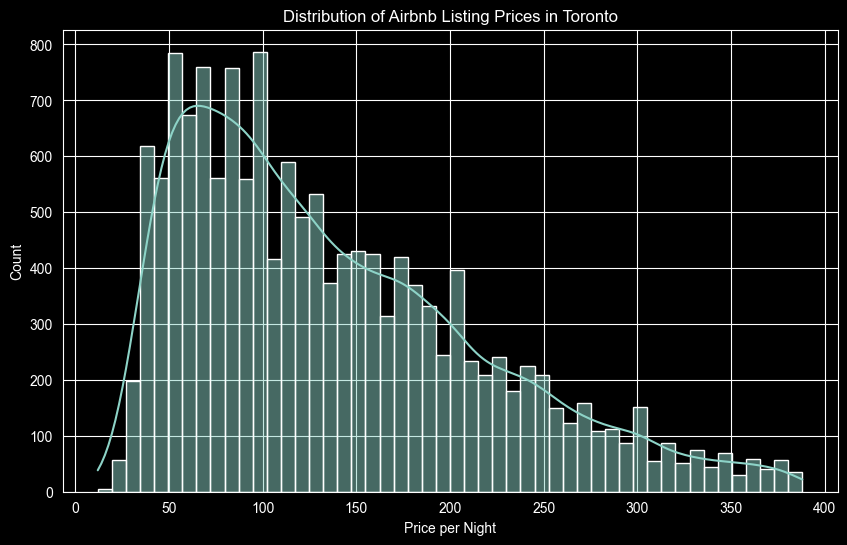

In [15]:
plt.figure(figsize=(10, 6))
sns.histplot(airbnb_eda["price"], bins=50, kde=True)
plt.title("Distribution of Airbnb Listing Prices in Toronto")
plt.xlabel("Price per Night")
plt.ylabel("Count")
plt.show()

Price by room type

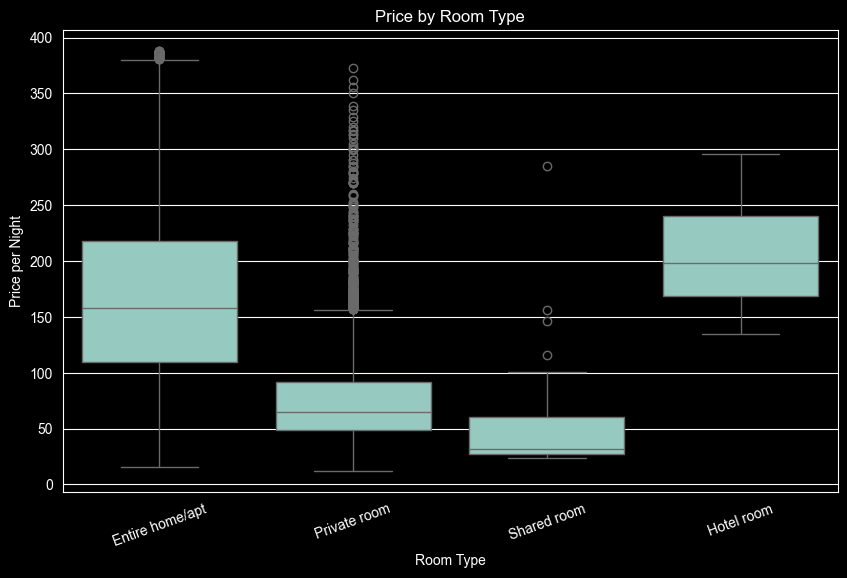

In [16]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=airbnb_eda, x="room_type", y="price")
plt.title("Price by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Price per Night")
plt.xticks(rotation=20)
plt.show()

Top neighbourhoods by average price

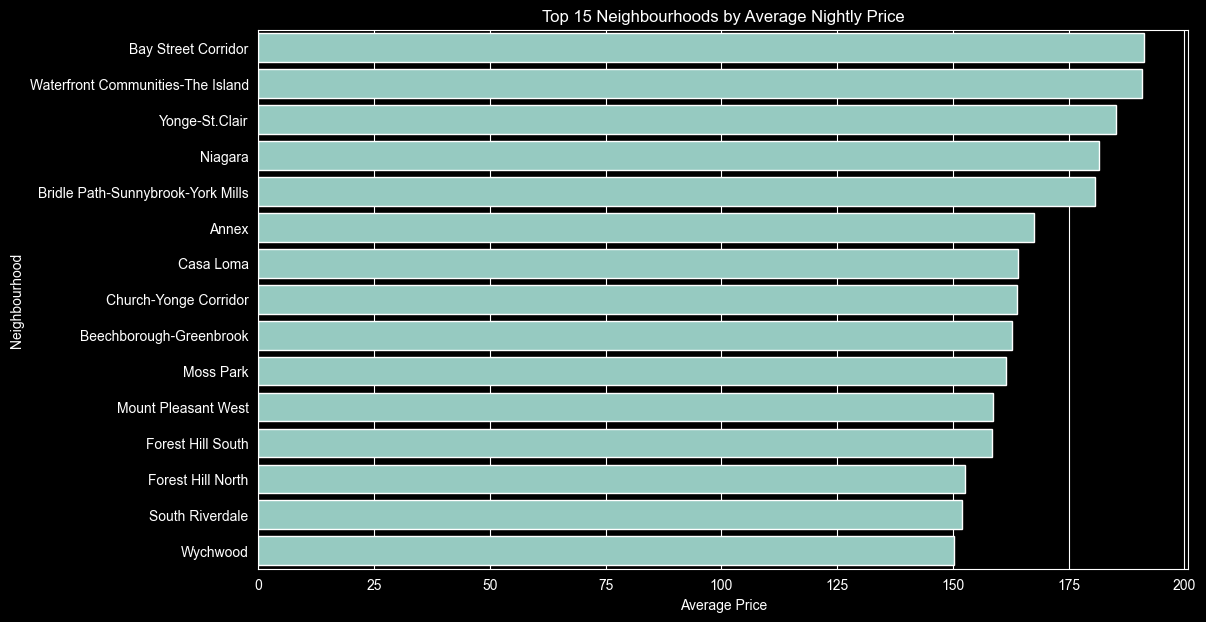

In [17]:
top_neighbourhoods = (
    airbnb_eda.groupby("neighbourhood_cleansed")["price"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
    .reset_index()
)

plt.figure(figsize=(12, 7))
sns.barplot(data=top_neighbourhoods, x="price", y="neighbourhood_cleansed")
plt.title("Top 15 Neighbourhoods by Average Nightly Price")
plt.xlabel("Average Price")
plt.ylabel("Neighbourhood")
plt.show()

Top neighbourhoods by occupancy proxy

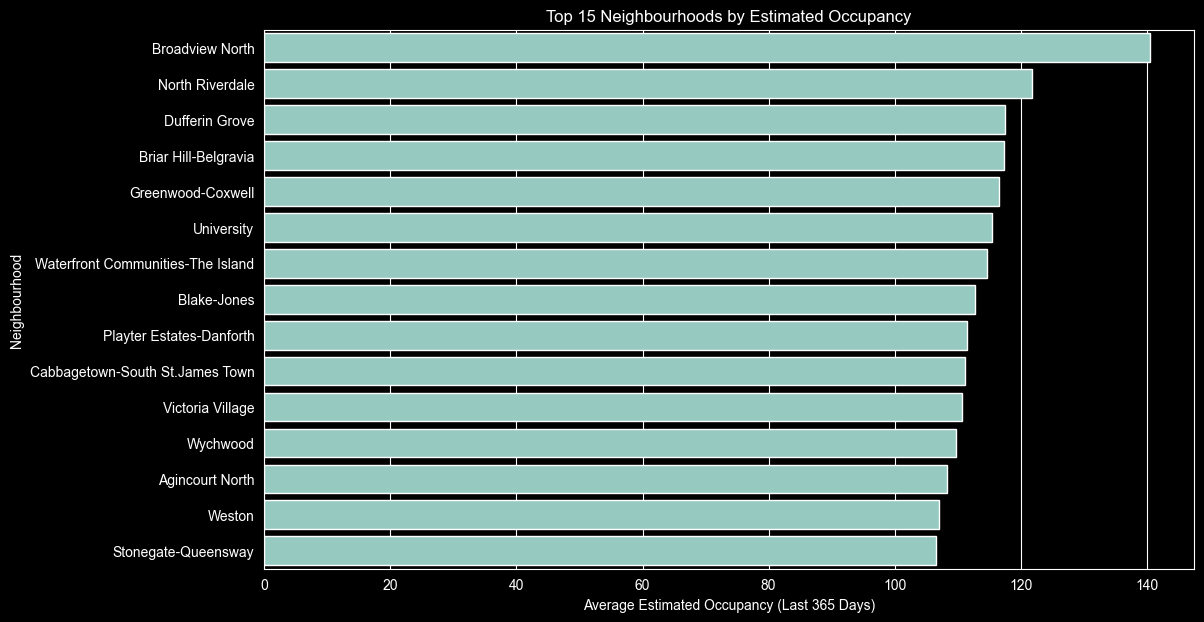

In [18]:
top_occupancy = (
    airbnb_eda.groupby("neighbourhood_cleansed")["estimated_occupancy_l365d"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
    .reset_index()
)

plt.figure(figsize=(12, 7))
sns.barplot(data=top_occupancy, x="estimated_occupancy_l365d", y="neighbourhood_cleansed")
plt.title("Top 15 Neighbourhoods by Estimated Occupancy")
plt.xlabel("Average Estimated Occupancy (Last 365 Days)")
plt.ylabel("Neighbourhood")
plt.show()

Price vs accommodates

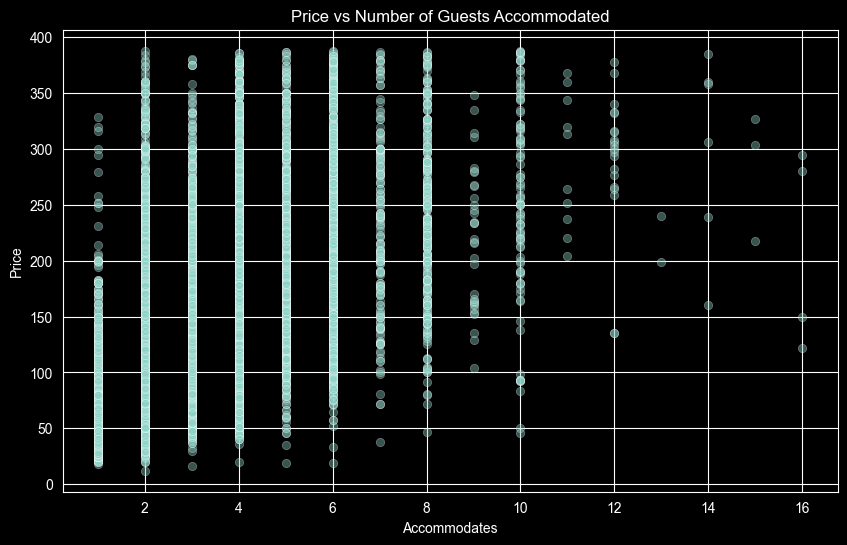

In [19]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=airbnb_eda, x="accommodates", y="price", alpha=0.4)
plt.title("Price vs Number of Guests Accommodated")
plt.xlabel("Accommodates")
plt.ylabel("Price")
plt.show()

Correlation heatmap

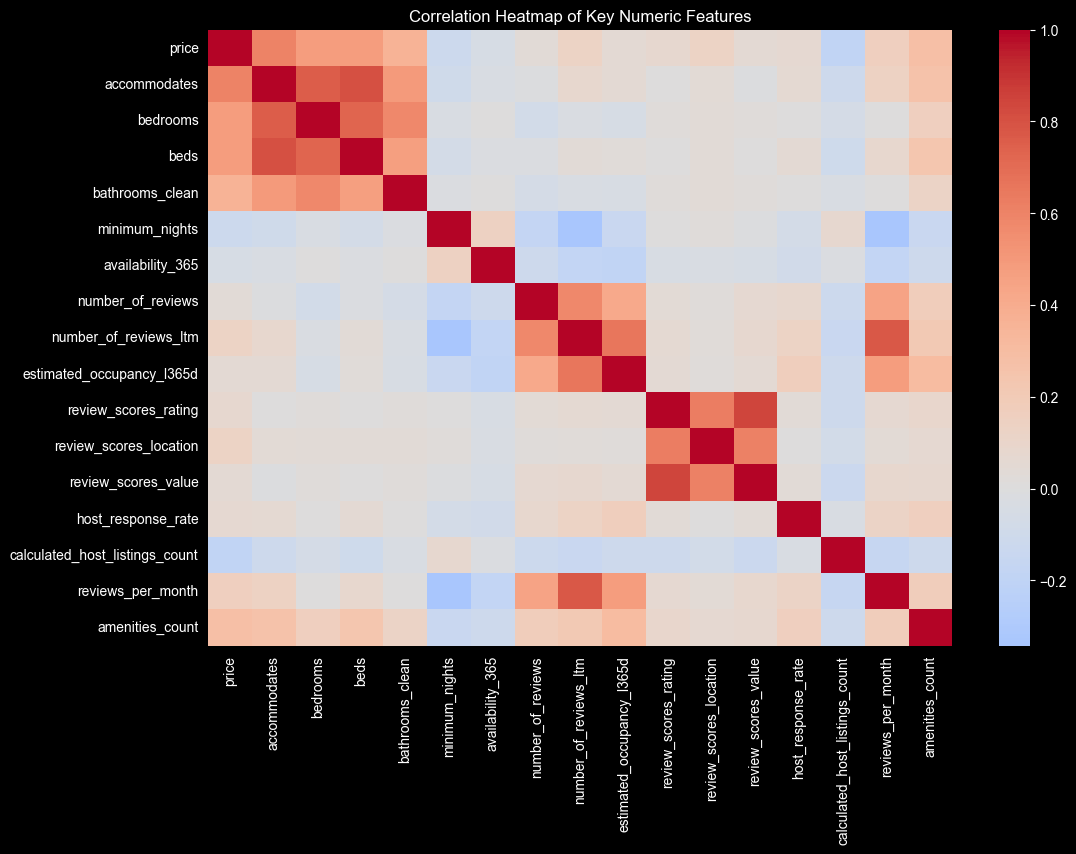

In [20]:
numeric_cols = [
    "price", "accommodates", "bedrooms", "beds", "bathrooms_clean",
    "minimum_nights", "availability_365", "number_of_reviews",
    "number_of_reviews_ltm", "estimated_occupancy_l365d",
    "review_scores_rating", "review_scores_location",
    "review_scores_value", "host_response_rate",
    "calculated_host_listings_count", "reviews_per_month",
    "amenities_count"
]

corr = airbnb_eda[numeric_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Key Numeric Features")
plt.show()

Geographic scatterplot of listings by price

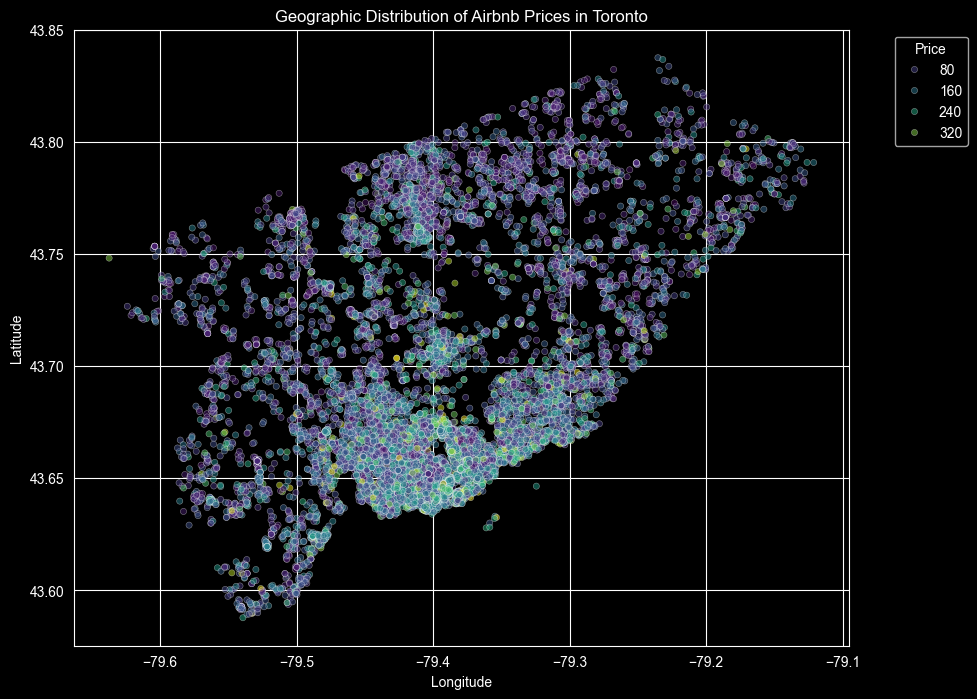

In [21]:
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=airbnb_eda,
    x="longitude",
    y="latitude",
    hue="price",
    palette="viridis",
    alpha=0.5,
    s=20
)
plt.title("Geographic Distribution of Airbnb Prices in Toronto")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title="Price", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

Room type share

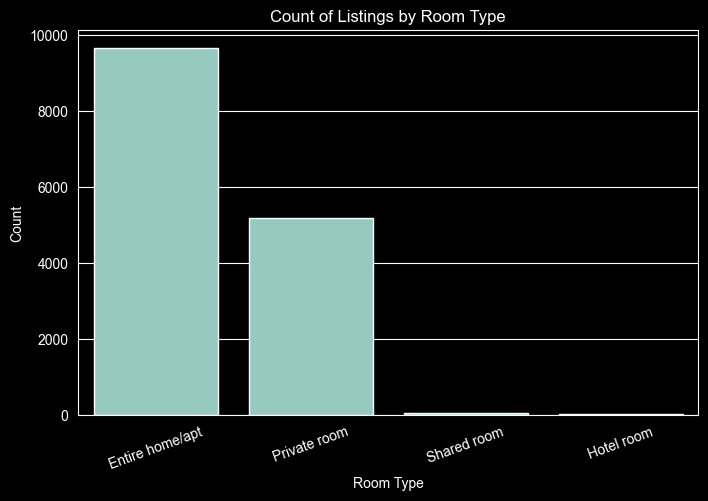

In [22]:
plt.figure(figsize=(8, 5))
sns.countplot(data=airbnb_eda, x="room_type", order=airbnb_eda["room_type"].value_counts().index)
plt.title("Count of Listings by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Count")
plt.xticks(rotation=20)
plt.show()

Superhost vs non-superhost price comparison

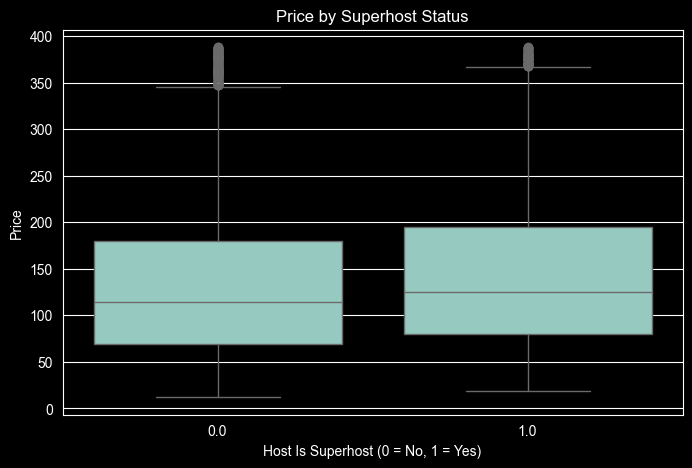

In [23]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=airbnb_eda, x="host_is_superhost", y="price")
plt.title("Price by Superhost Status")
plt.xlabel("Host Is Superhost (0 = No, 1 = Yes)")
plt.ylabel("Price")
plt.show()

**KEY INSIGHTS**
- Airbnb prices in Toronto are highly right-skewed.
- Entire homes command significantly higher prices than private/shared rooms.
- Location plays a major role in pricing, with certain neighbourhoods showing clear price premiums.
- Listing size and capacity (accommodates, bedrooms) are important drivers of price.
- Occupancy-related variables suggest variation in demand across neighbourhoods.

Encoding and Scaling

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

# a function to group all rare property types into an 'other' category for OneHotEncoding

counts = airbnb['property_type'].value_counts()
def replace_rare(x):
    threshold = 100
    if counts[x] >= threshold:
        return x
    else:
        return 'Other'

airbnb['property_type'] = airbnb['property_type'].apply(replace_rare)

feature_cols = [
    'room_type',
    'property_type',
    'accommodates',
    'bedrooms',
    'beds',
    'bathrooms_clean',
    'amenities_count',
    'minimum_nights',
    'review_scores_rating',
    'review_scores_location',
    'review_scores_value',
    'host_is_superhost',
    'instant_bookable',
    'host_response_rate',
    'calculated_host_listings_count',
    'neighbourhood_cleansed'
]

x = airbnb_eda[feature_cols]
y=np.log1p(airbnb_eda['price']) #log-scaling for hugely skewed price distribution

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [25]:
oneHotCols = ['room_type', 'property_type']

encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
encoder.fit(x_train[oneHotCols])

x_train['neighbourhood_encoded'] = x_train['neighbourhood_cleansed'].map(
    y_train.groupby(x_train['neighbourhood_cleansed']).mean()
)
x_test['neighbourhood_encoded'] = x_test['neighbourhood_cleansed'].map(
    y_train.groupby(x_train['neighbourhood_cleansed']).mean()
)

x_train = x_train.drop(columns=['neighbourhood_cleansed'])
x_test = x_test.drop(columns=['neighbourhood_cleansed'])

encoded_train = pd.DataFrame(
    encoder.transform(x_train[oneHotCols]),
    columns=encoder.get_feature_names_out(oneHotCols),
    index=x_train.index
)

encoded_test = pd.DataFrame(
    encoder.transform(x_test[oneHotCols]),
    columns=encoder.get_feature_names_out(oneHotCols),
    index=x_test.index
)

x_train = x_train.drop(columns=oneHotCols)
x_test = x_test.drop(columns=oneHotCols)

x_train = pd.concat([x_train, encoded_train], axis=1)
x_test = pd.concat([x_test, encoded_test], axis=1)

Linear Regression

In [26]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Train
lr = LinearRegression()
lr.fit(x_train, y_train)

# Predict
y_pred_lr = lr.predict(x_test)

# Evaluate
rmse = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_pred_lr)))
r2 = r2_score(y_test, y_pred_lr)

print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.4f}")

RMSE: 56.59
R²: 0.6191


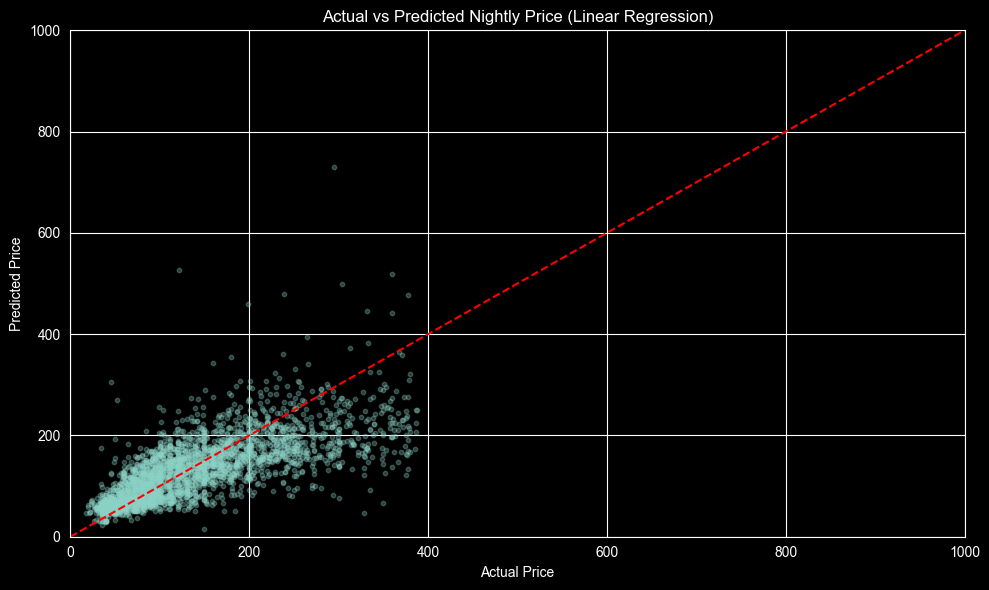

In [27]:
plt.figure(figsize=(10, 6))
plt.scatter(np.expm1(y_test), np.expm1(y_pred_lr), alpha=0.3, s=10)
plt.plot([0, 1000], [0, 1000], color='red', linewidth=1.5, linestyle='--')  # perfect prediction line
plt.xlim(0, 1000)
plt.ylim(0, 1000)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Nightly Price (Linear Regression)")
plt.tight_layout()
plt.show()

Random Forest Regression


Training R²: 0.7955
Test R²: 0.6989
OOB Score: 0.6880
Test RMSE: 51.21 $/night
                           feature  importance
         room_type_Entire home/apt    0.126572
                      accommodates    0.125044
            room_type_Private room    0.112135
             neighbourhood_encoded    0.097827
property_type_Private room in home    0.088841
                          bedrooms    0.063779
                              beds    0.058215
                    minimum_nights    0.054519
    calculated_host_listings_count    0.054325
                   amenities_count    0.045990


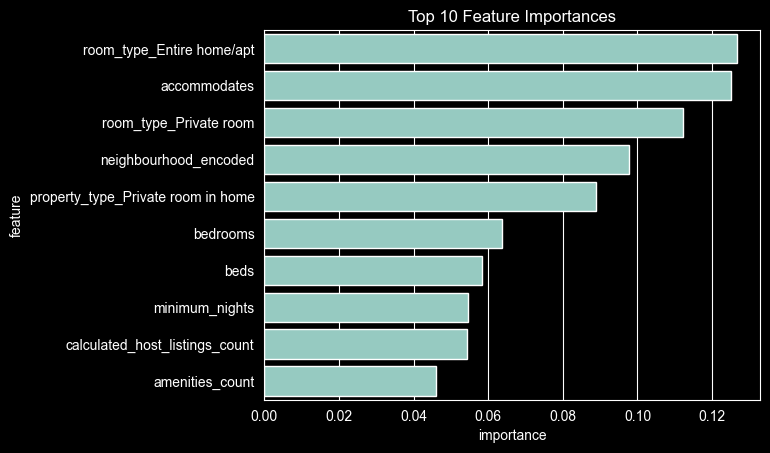

In [28]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42,
                           oob_score=True,
                            max_depth=15,
                            min_samples_leaf=2,
                            max_features='sqrt',
                            n_estimators=200
)
rf.fit(x_train, y_train)

importances = rf.feature_importances_
featureNames = x_train.columns

importanceDF = pd.DataFrame({'feature': featureNames, 'importance': importances})
importanceDF = importanceDF.sort_values('importance', ascending=False).head(10)

# Calculate R² for the training set
y_train_pred = rf.predict(x_train)
r2_train = r2_score(y_train, y_train_pred)

# Calculate R² for the test set
y_test_pred = rf.predict(x_test)
r2_test = r2_score(y_test, y_test_pred)

# Calculate RMSE for the test set
rmse_test = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_test_pred)))

print(f"\nTraining R²: {r2_train:.4f}")
print(f"Test R²: {r2_test:.4f}")
print(f"OOB Score: {rf.oob_score_:.4f}")
print(f"Test RMSE: {rmse_test:.2f} $/night")

sns.barplot(data=importanceDF, x='importance', y='feature')
print(importanceDF[['feature', 'importance']].to_string(index=False))
plt.title('Top 10 Feature Importances')
plt.show()

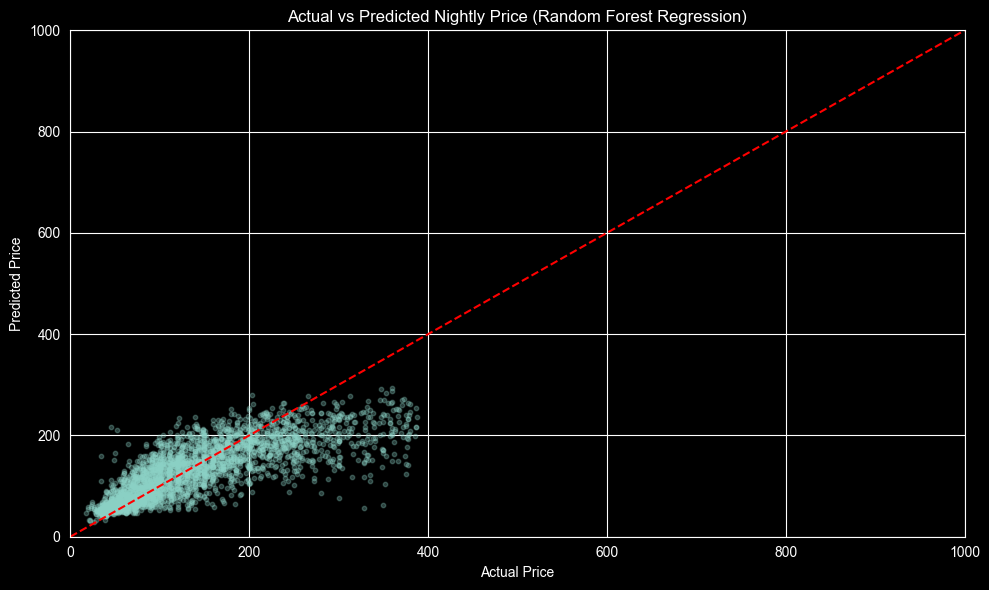

In [30]:
plt.figure(figsize=(10, 6))
plt.scatter(np.expm1(y_test), np.expm1(y_test_pred), alpha=0.3, s=10)
plt.plot([0, 1000], [0, 1000], color='red', linewidth=1.5, linestyle='--')  # perfect prediction line
plt.xlim(0, 1000)
plt.ylim(0, 1000)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Nightly Price (Random Forest Regression)")
plt.tight_layout()
plt.show()

---

**CLUSTERING ANALYSIS AND GEOSPATIAL VISUALIZATION (Research Question 2)**

Remove extreme price outliers and drop rows with missing lat/long

In [31]:
# Remove price outliers using IQR method
q1 = airbnb["price"].quantile(0.25)
q3 = airbnb["price"].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

airbnb_clean = airbnb[(airbnb["price"] >= lower_bound) & (airbnb["price"] <= upper_bound)].copy()

# Drop any rows where latitude or longitude is missing
airbnb_clean = airbnb_clean.dropna(subset=["latitude", "longitude"])

print("Original rows:", airbnb.shape[0])
print("Rows after filtering:", airbnb_clean.shape[0])

Original rows: 15809
Rows after filtering: 14874


Extract latitude and longitude for clustering

In [32]:
# Extract the two features used for geospatial clustering

X = airbnb_clean[["latitude", "longitude"]].values

print("Shape of feature array:", X.shape)
print("First 5 rows:")
print(X[:5])

Shape of feature array: (14874, 2)
First 5 rows:
[[ 43.64608 -79.39032]
 [ 43.66884 -79.32725]
 [ 43.67239 -79.28858]
 [ 43.67193 -79.3859 ]
 [ 43.67129 -79.38634]]


Standardize the features using StandardScaler

In [33]:
# K-Means is a distance-based algorithm, therefore normalize the data.

from sklearn.preprocessing import StandardScaler

X = StandardScaler().fit_transform(X)

print("Scaled feature sample:")
print(X[:5])

Scaled feature sample:
[[-0.80144266  0.0977997 ]
 [-0.35707434  0.95264522]
 [-0.28776382  1.47677517]
 [-0.2967449   0.15770801]
 [-0.30924032  0.15174429]]


Visualize the raw data points before clustering

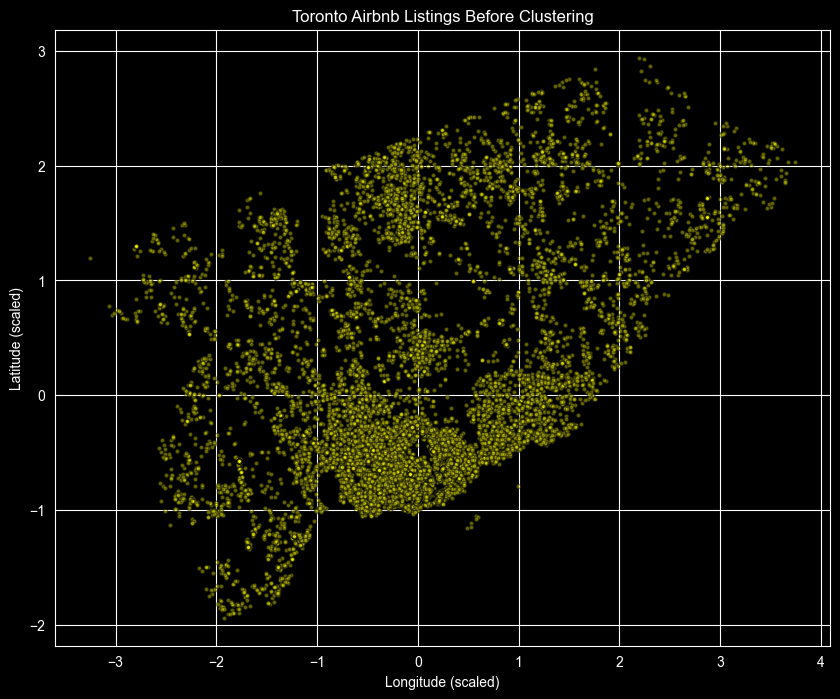

In [34]:
# Plot the raw data points before clustering to visualize geographic spread

plt.figure(figsize=(10, 8))
plt.scatter(X[:, 1], X[:, 0], c='yellow', marker='o', edgecolor='black', s=10, alpha=0.4)
plt.title("Toronto Airbnb Listings Before Clustering")
plt.xlabel("Longitude (scaled)")
plt.ylabel("Latitude (scaled)")
plt.show()

Apply the Elbow Method to find the best value of K

K=2, WCSS (inertia): 16181.25
K=3, WCSS (inertia): 10908.16
K=4, WCSS (inertia): 7500.94
K=5, WCSS (inertia): 5947.69
K=6, WCSS (inertia): 5464.68
K=7, WCSS (inertia): 4344.74
K=8, WCSS (inertia): 3464.71
K=9, WCSS (inertia): 2990.34
K=10, WCSS (inertia): 2684.78


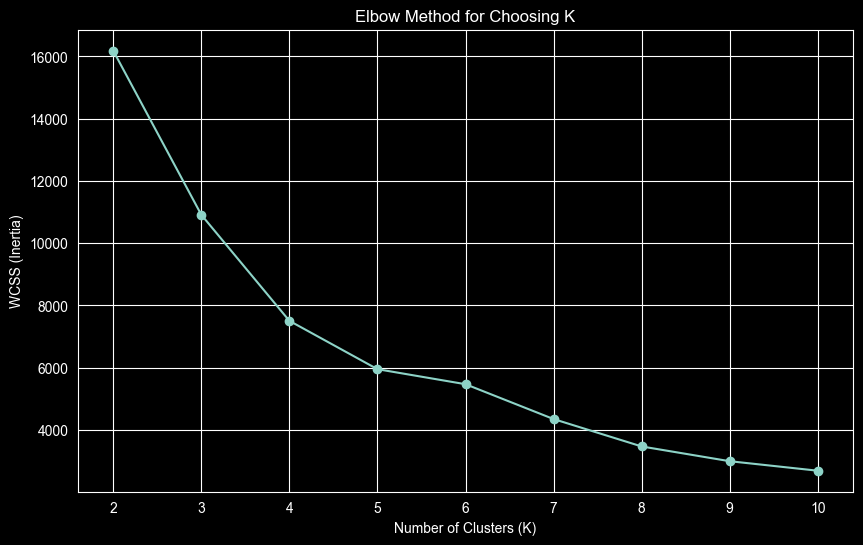

In [35]:
# Try different values of K and record the Within-Cluster Sum of Squares (WCSS) for each K.
# WCSS is accessed via km.inertia_ after fitting.

from sklearn.cluster import KMeans

wcss = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=0)
    km.fit(X)
    wcss.append(km.inertia_)
    print(f"K={k}, WCSS (inertia): {km.inertia_:.2f}")

plt.figure(figsize=(10, 6))
plt.plot(list(k_range), wcss, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS (Inertia)")
plt.title("Elbow Method for Choosing K")
plt.show()

Evaluate cluster quality using silhouette score for each K

K=2, Silhouette Score: 0.5130
K=3, Silhouette Score: 0.4781
K=4, Silhouette Score: 0.4963
K=5, Silhouette Score: 0.4810
K=6, Silhouette Score: 0.3609
K=7, Silhouette Score: 0.3724
K=8, Silhouette Score: 0.4677
K=9, Silhouette Score: 0.4611
K=10, Silhouette Score: 0.4132


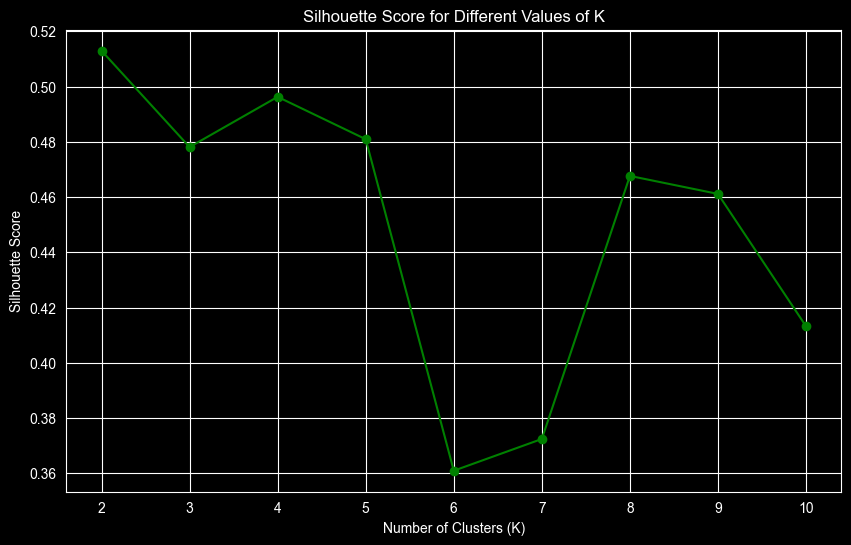

In [36]:
# The silhouette score measures how well each point fits within its assigned cluster compared to other clusters.
# It ranges from -1 to 1, where a higher value means the clusters are well separated and compact.

from sklearn.metrics import silhouette_score

sil_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=0)
    labels = km.fit_predict(X)
    score = silhouette_score(X, labels)
    sil_scores.append(score)
    print(f"K={k}, Silhouette Score: {score:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(list(k_range), sil_scores, marker="o", color="green")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different Values of K")
plt.show()

Justification for choosing K=4

Using the Elbow Method as our primary approach, the WCSS curve shows a clear elbow at K=4. The drop from K=3 to K=4 (3,407) is more than double the drop from K=4 to K=5 (1,553), after which the curve flattens significantly. This indicates that adding a fifth cluster provides diminishing returns in terms of compactness.

The silhouette score analysis raises the question of why not K=2 as K=2 evidently achieved the highest silhouette score of 0.513 compared to K=4 with 0.496. However, K=2 only produces two segments, effectively splitting Toronto into a downtown core versus everything else. This does not provide the granularity needed to answer Research Question 2, which asks how location influences price premiums and occupancy rates across the city. K=4 reveals three distinct tiers of market segments beyond the downtown core: a mid-range west-end zone (Cluster 0), a lower-priced northern zone (Cluster 1), and a lower-priced eastern zone (Cluster 2). Each segment now offer meaningfully different price points, occupancy levels, and room type compositions. The marginal difference in silhouette score (0.017) is a small trade-off for a significantly richer segmentation.

Fit K-Means with the chosen K

In [37]:
# Based on the Elbow Method and Silhouette Score plots above, select the K at the elbow point.
# UPDATE the value of chosen_k below based on your results.

chosen_k = 4

# fit_predict(X) fits the K-means model to the data and returns the cluster label for each observation

km = KMeans(n_clusters=chosen_k, random_state=0)
y_km = km.fit_predict(X)

# Display the cluster label assigned to each point where labels such as 0, 1, 2 are arbitrary IDs
print("Cluster labels (first 20):", y_km[:20])
print("\nPoints per cluster:")
print(pd.Series(y_km).value_counts().sort_index())

Cluster labels (first 20): [3 3 3 3 3 3 3 3 3 3 3 3 3 0 3 3 3 3 3 3]

Points per cluster:
0    2295
1    2167
2    1931
3    8481
Name: count, dtype: int64


Add cluster labels back to the dataframe

In [38]:
# Assign the cluster labels to each listing so we can analyze price and occupancy by cluster

airbnb_clean["cluster"] = y_km

airbnb_clean[["neighbourhood_cleansed", "latitude", "longitude", "price", "cluster"]].head(10)

,neighbourhood_cleansed,latitude,longitude,price,cluster
2,Waterfront Communities-The Island,43.64608,-79.39032,133.0,3
3,South Riverdale,43.66884,-79.32725,75.0,3
6,The Beaches,43.67239,-79.28858,85.0,3
7,Rosedale-Moore Park,43.67193,-79.38590,97.0,3
8,Rosedale-Moore Park,43.67129,-79.38634,88.0,3
9,Bay Street Corridor,43.66123,-79.38336,120.0,3
10,Rosedale-Moore Park,43.67180,-79.38488,70.0,3
11,Church-Yonge Corridor,43.66899,-79.38559,160.0,3
13,Niagara,43.64453,-79.40736,64.0,3
14,Niagara,43.64475,-79.40905,79.0,3


Visualize the clusters and centroids on scaled coordinates

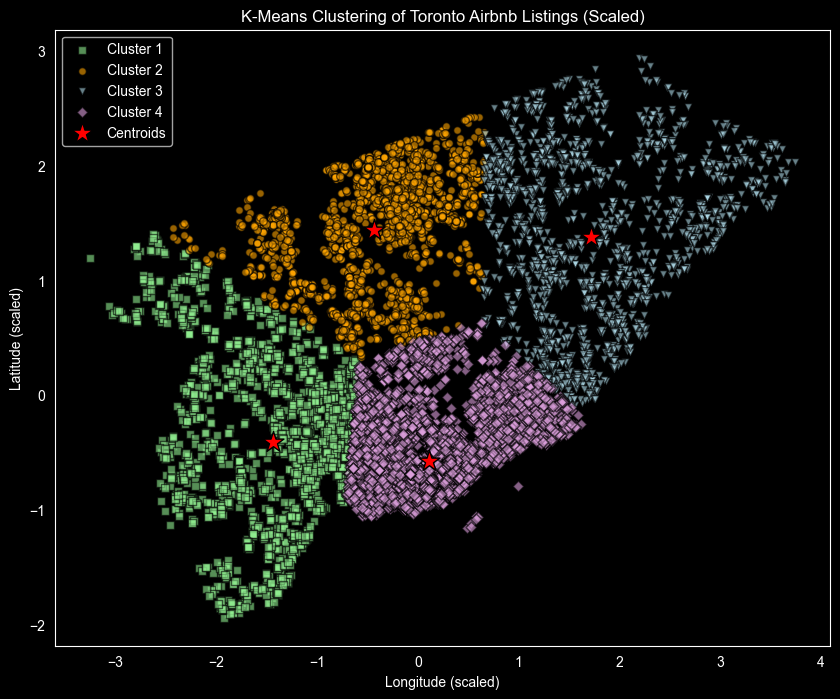

In [39]:
# Plot points colored by cluster, then overlay centroids as red stars.
# km.cluster_centers_ is an array of shape (k, number_of_features)

colors = ["lightgreen", "orange", "lightblue", "plum", "gold", "salmon", "cyan", "pink", "lime"]
markers = ["s", "o", "v", "D", "^", "p", "*", "X", "h"]

plt.figure(figsize=(10, 8))

for i in range(chosen_k):
    plt.scatter(
        X[y_km == i, 1], X[y_km == i, 0],
        s=30, c=colors[i], marker=markers[i],
        edgecolor="black", label=f"Cluster {i + 1}", alpha=0.6
    )

# Plot the centroids
plt.scatter(
    km.cluster_centers_[:, 1], km.cluster_centers_[:, 0],
    s=250, marker="*", c="red", edgecolor="black", label="Centroids"
)

plt.title("K-Means Clustering of Toronto Airbnb Listings (Scaled)")
plt.xlabel("Longitude (scaled)")
plt.ylabel("Latitude (scaled)")
plt.legend(scatterpoints=1)
plt.grid()
plt.show()

Geospatial visualization using original lat/long coordinates

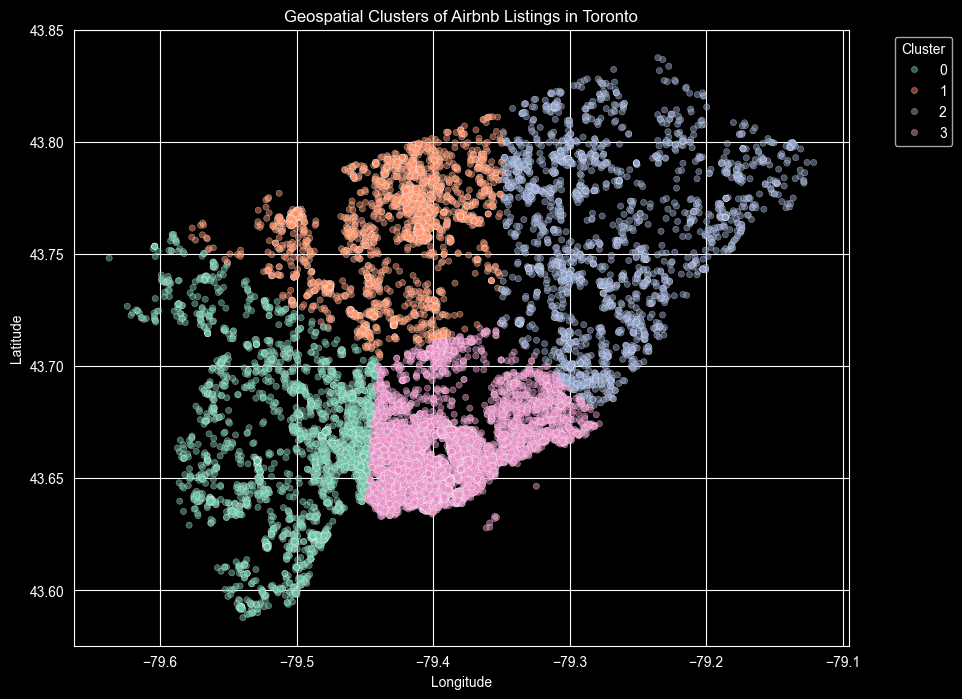

In [40]:
# Plot the clusters on actual geographic coordinates so the map is interpretable as real Toronto locations.

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=airbnb_clean,
    x="longitude",
    y="latitude",
    hue="cluster",
    palette="Set2",
    alpha=0.5,
    s=20
)
plt.title("Geospatial Clusters of Airbnb Listings in Toronto")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

Average price by cluster

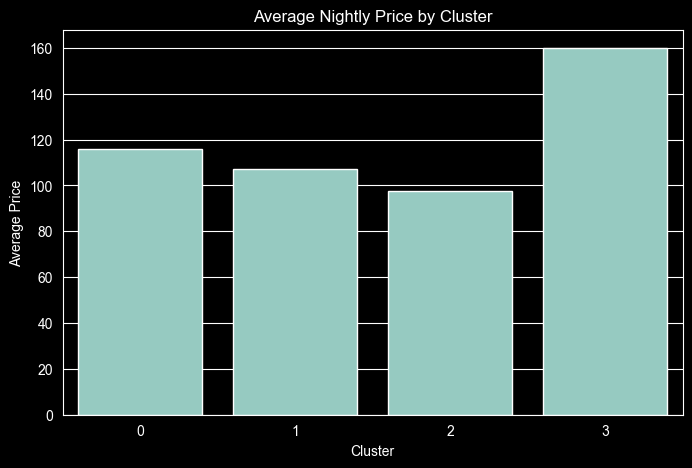

In [41]:
# Group by cluster and compute mean price

cluster_price = (
    airbnb_clean.groupby("cluster")["price"]
    .mean()
    .reset_index()
)
cluster_price.columns = ["Cluster", "Average Price"]

plt.figure(figsize=(8, 5))
sns.barplot(data=cluster_price, x="Cluster", y="Average Price")
plt.title("Average Nightly Price by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Price")
plt.show()

Average estimated occupancy by cluster

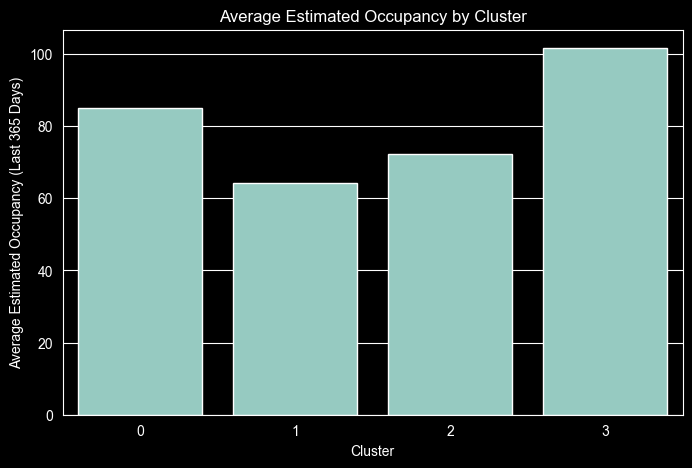

In [42]:
# Group by cluster and compute mean estimated occupancy

cluster_occupancy = (
    airbnb_clean.groupby("cluster")["estimated_occupancy_l365d"]
    .mean()
    .reset_index()
)
cluster_occupancy.columns = ["Cluster", "Average Estimated Occupancy"]

plt.figure(figsize=(8, 5))
sns.barplot(data=cluster_occupancy, x="Cluster", y="Average Estimated Occupancy")
plt.title("Average Estimated Occupancy by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Estimated Occupancy (Last 365 Days)")
plt.show()

Average number of reviews by cluster

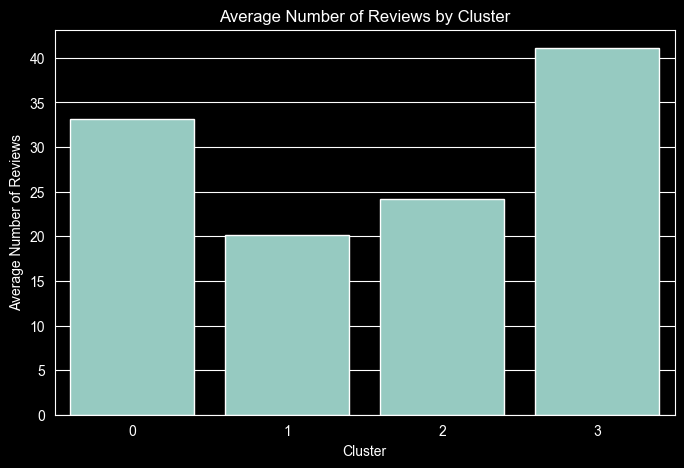

In [43]:
# Number of reviews as a secondary proxy for demand/popularity

cluster_reviews = (
    airbnb_clean.groupby("cluster")["number_of_reviews"]
    .mean()
    .reset_index()
)
cluster_reviews.columns = ["Cluster", "Average Number of Reviews"]

plt.figure(figsize=(8, 5))
sns.barplot(data=cluster_reviews, x="Cluster", y="Average Number of Reviews")
plt.title("Average Number of Reviews by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Number of Reviews")
plt.show()

Full cluster summary table

In [44]:
# Aggregate multiple columns at once using groupby and mean

cluster_summary = airbnb_clean.groupby("cluster").agg(
    count=("price", "size"),
    avg_price=("price", "mean"),
    avg_occupancy=("estimated_occupancy_l365d", "mean"),
    avg_reviews=("number_of_reviews", "mean"),
    avg_review_score=("review_scores_rating", "mean"),
    avg_availability=("availability_365", "mean")
).reset_index()

# Round for readability
cluster_summary = cluster_summary.round(2)

print("Cluster Summary:")
cluster_summary

Cluster Summary:


,cluster,count,avg_price,avg_occupancy,avg_reviews,avg_review_score,avg_availability
0,0,2295,115.83,85.08,33.14,4.82,235.79
1,1,2167,107.30,64.18,20.14,4.77,229.38
2,2,1931,97.73,72.10,24.16,4.78,244.22
3,3,8481,159.88,101.58,41.10,4.82,216.55


Price distribution within each cluster

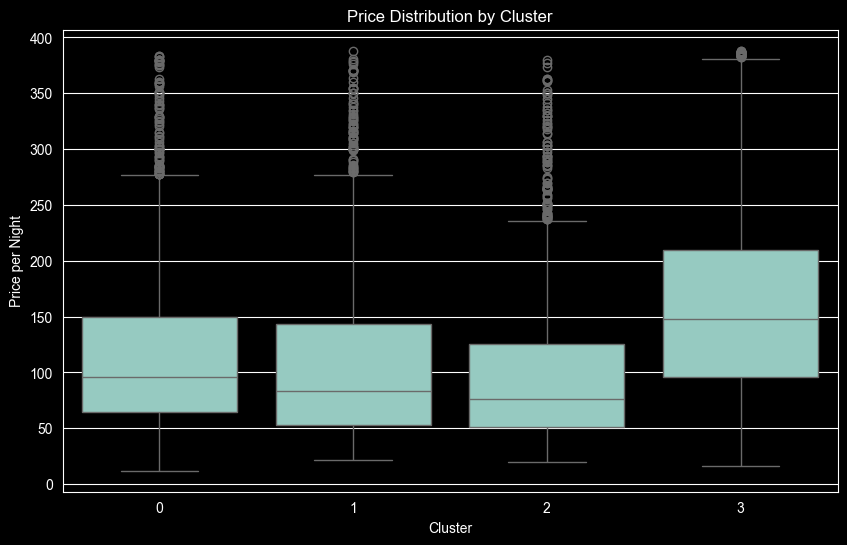

In [45]:
# Boxplot to show the spread of prices within each cluster

plt.figure(figsize=(10, 6))
sns.boxplot(data=airbnb_clean, x="cluster", y="price")
plt.title("Price Distribution by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Price per Night")
plt.show()

Occupancy distribution by cluster

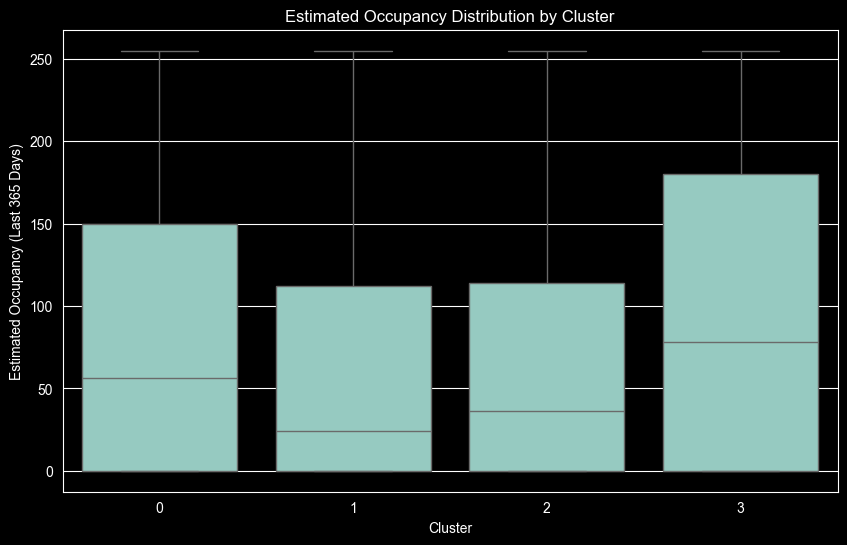

Occupancy Standard Deviation by Cluster:
cluster
0    89.04
1    83.50
2    87.82
3    95.40
Name: estimated_occupancy_l365d, dtype: float64


In [46]:
# Boxplot to compare the spread of occupancy across clusters
# This is needed to verify whether the difference between Cluster 1 and Cluster 2 occupancy is substantive or within normal variation

plt.figure(figsize=(10, 6))
sns.boxplot(data=airbnb_clean, x="cluster", y="estimated_occupancy_l365d")
plt.title("Estimated Occupancy Distribution by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Estimated Occupancy (Last 365 Days)")
plt.show()

# Standard deviation per cluster to quantify the spread
print("Occupancy Standard Deviation by Cluster:")
print(airbnb_clean.groupby("cluster")["estimated_occupancy_l365d"].std().round(2))

Room type composition within each cluster

Room Type Proportion by Cluster:
room_type  Entire home/apt  Hotel room  Private room  Shared room
cluster                                                          
0                    0.567       0.000         0.432        0.001
1                    0.438       0.000         0.557        0.005
2                    0.434       0.000         0.563        0.002
3                    0.773       0.002         0.223        0.003


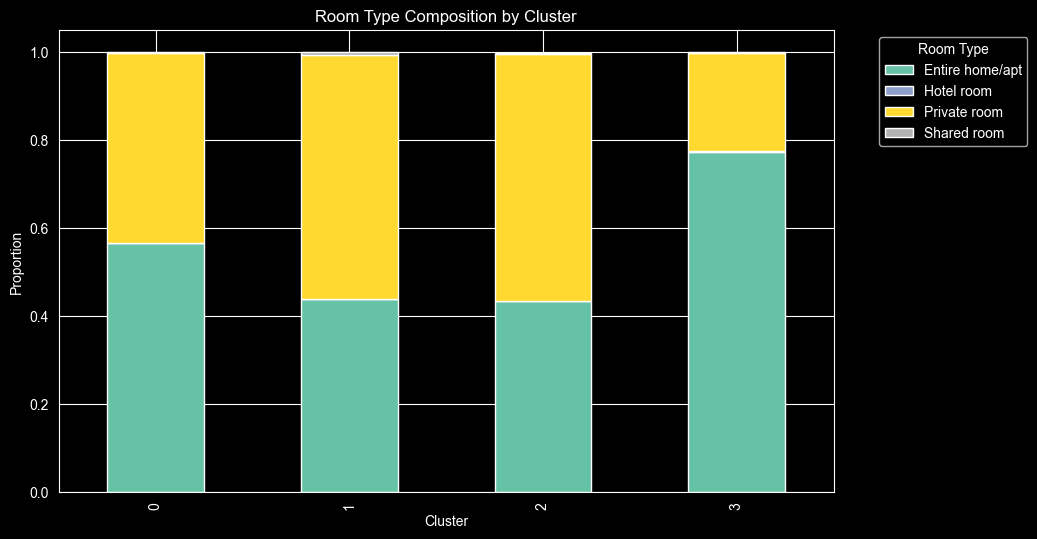

In [47]:
# Cross-tabulate room type and cluster to see which clusters have more entire homes vs private rooms

room_by_cluster = pd.crosstab(
    airbnb_clean["cluster"],
    airbnb_clean["room_type"],
    normalize="index"
).round(3)

print("Room Type Proportion by Cluster:")
print(room_by_cluster)

# Stacked bar chart
room_by_cluster.plot(kind="bar", stacked=True, figsize=(10, 6), colormap="Set2")
plt.title("Room Type Composition by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Proportion")
plt.legend(title="Room Type", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

Top neighbourhoods in each cluster

In [48]:
# Show which neighbourhoods fall into each cluster and interpret what each cluster represents geographically

for c in range(chosen_k):
    top = (
        airbnb_clean[airbnb_clean["cluster"] == c]
        .groupby("neighbourhood_cleansed")["price"]
        .agg(["count", "mean"])
        .sort_values("count", ascending=False)
        .head(5)
        .round(2)
    )
    print(f"\n--- Cluster {c} - Top 5 Neighbourhoods ---")
    print(top)


--- Cluster 0 - Top 5 Neighbourhoods ---
                                     count    mean
neighbourhood_cleansed                            
Mimico (includes Humber Bay Shores)    190  147.19
Islington-City Centre West             155  118.88
High Park-Swansea                      137  140.05
Junction Area                          129  132.97
Rockcliffe-Smythe                      102   92.31

--- Cluster 1 - Top 5 Neighbourhoods ---
                         count    mean
neighbourhood_cleansed                
Willowdale East            336  128.70
York University Heights    199   67.72
Newtonbrook East           165   97.27
Newtonbrook West           143   90.12
Willowdale West            132  111.27

--- Cluster 2 - Top 5 Neighbourhoods ---
                        count   mean
neighbourhood_cleansed              
Wexford/Maryvale          127  97.98
L'Amoreaux                118  73.79
Pleasant View             100  73.21
West Hill                  97  94.69
Parkwoods-Donalda     

Cluster-level vs neighbourhood-level comparison

In [49]:
# Compare whether clustering on lat/long reveals patterns that neighbourhood-level groupby alone does not.
# If multiple neighbourhoods within the same cluster show similar price/occupancy profiles despite being separate named areas, the clustering has identified a broader geographic pattern.

neighbourhood_stats = (
    airbnb_clean.groupby(["cluster", "neighbourhood_cleansed"])
    .agg(
        count=("price", "size"),
        avg_price=("price", "mean"),
        avg_occupancy=("estimated_occupancy_l365d", "mean")
    )
    .reset_index()
)

# Show the within-cluster standard deviation of neighbourhood-level averages
# A low std means neighbourhoods within that cluster behave similarly, confirming the cluster captures a real geographic market pattern
print("Within-Cluster Variation of Neighbourhood Avg Prices:")
print(neighbourhood_stats.groupby("cluster")["avg_price"].std().round(2))

print("\nWithin-Cluster Variation of Neighbourhood Avg Occupancy:")
print(neighbourhood_stats.groupby("cluster")["avg_occupancy"].std().round(2))

print("\nNumber of Distinct Neighbourhoods per Cluster:")
print(neighbourhood_stats.groupby("cluster")["neighbourhood_cleansed"].nunique())

Within-Cluster Variation of Neighbourhood Avg Prices:
cluster
0    22.17
1    32.07
2    21.29
3    26.13
Name: avg_price, dtype: float64

Within-Cluster Variation of Neighbourhood Avg Occupancy:
cluster
0    28.71
1    21.76
2    18.79
3    27.38
Name: avg_occupancy, dtype: float64

Number of Distinct Neighbourhoods per Cluster:
cluster
0    47
1    34
2    37
3    54
Name: neighbourhood_cleansed, dtype: int64


Print final silhouette score for the chosen K

In [50]:
# Report the silhouette score for the chosen K

final_score = silhouette_score(X, y_km)
print(f"Final Silhouette Score (K={chosen_k}): {final_score:.4f}")

Final Silhouette Score (K=4): 0.4963


The Elbow Method identified K=4 as the optimal number of clusters based on the inflection point at which the WCSS curve begins to flatten, where the marginal reduction from K=3 to K=4 (3,407) is more than double the reduction from K=4 to K=5 (1,553), confirming diminishing returns beyond four clusters. While silhouette score analysis indicated K=2 as the highest-scoring configuration at 0.513, a binary segmentation would reduce the clustering to a downtown versus non-downtown split, which lacks the granularity required to meaningfully address Research Question 2 regarding how location influences price premiums and occupancy rates across the city. K=4 achieves a silhouette score of 0.496, confirming well-separated and internally compact clusters while producing the distinct market tiers outlined in our proposal. The marginal difference of 0.017 therefore represents a reasonable trade-off for the significantly richer segmentation that K=4 provides.

The four geographic segments reveal meaningful variation in pricing, demand and listing composition across Toronto. Cluster 3, the downtown core, contains the largest concentration of listings at 8,481 and commands both the highest average nightly price (\$159.88) and the highest estimated occupancy (101.58). Entire home listings account for 77.3% of this cluster, with Waterfront Communities, Niagara and the Annex emerging as the dominant neighbourhoods, consistent with the concentration of premium short-term rental supply along Toronto's central corridor. Cluster 0 encompasses the west end, comprising 2,295 listings at a mid-range average price of $115.83 and moderate estimated occupancy of 85.08, with Mimico, Islington-City Centre West and High Park-Swansea serving as the primary neighbourhood anchors. Cluster 1 captures the northern periphery with 2,167 listings, recording both the lowest average price (\$107.30) and the lowest estimated occupancy (64.18). Private rooms constitute a majority of the listings in from cluster 1 at 55.7%, concentrated in Willowdale East and York University Heights. Cluster 2 represents the east and Scarborough area with 1,931 listings at the lowest average price of \$97.73, yet demonstrates higher occupancy at 72.10 than the north cluster despite lower pricing relative to other GTA counterparts. This confirms the hypothesis outlined in our proposal that certain areas of the city sustain strong demand without commanding premium nightly rates.

This divergence between occupancy and price across clusters is particularly notable. Cluster 2 outperforming Cluster 1 in estimated occupancy despite commanding lower average nightly rates suggest an opportunity for hosts seeking consistent booking or utility rather than premium pricing. The variation in room type compsition of 77% entire homes in the downtore core compare to over 55% private rooms within the north and east clusters also suggest that different geographic zones attract distinct host strategies and traveller demographics. Geospatial clustering can be leveraged to identify market segments that a neightbourhood-level analysis could not reveal.

Limitations

Cluster 3 contains 57% of the dataset (8,481 of 14,874 listings), meaning the model assigns the majority of listings to a single downtown segment while splitting the remaining 43% into three smaller clusters. This imbalance suggests the downtown core is disproportionately dominant in the data, and the three outer clusters are subdivisions of the non-downtown remainder rather than equally weighted market segments.

The elbow at K=4 involves a degree of judgment. The WCSS drops from K=4 to K=5 (1,553) and K=5 to K=6 (483) both represent flattening, meaning K=5 could also be argued as a valid elbow point. The selection of K=4 was guided by the combination of the WCSS curve and the silhouette score, but it is not the only defensible choice.

Clustering on latitude and longitude alone means the algorithm is partitioning geographic space based on proximity. The resulting clusters are functionally geographic zones, not market segments derived from behavioural or listing-level features. Differences in price and occupancy observed across clusters are therefore differences across areas of the city, which could partially be captured by grouping on the existing neighbourhood variable. The cluster-level versus neighbourhood-level comparison above helps assess whether the clustering adds analytical value beyond what neighbourhood groupby alone provides.